# Practice 5.
##  Objectives:
1. Understand the projection methods for classification.
2. Understand the Fisher discriminant.

2. Do a simple exploratory data analysis
3. Learn the **data cleaning and visualitzation** features of Pandas.
## Aplication:
Data basse: Data set from the UCI Machine Learning Repository
(http://archive.ics.uci.edu/ml)

 Database: Wine quality, http://archive.ics.uci.edu/ml/datasets/Wine+Quality
- Predict **quality** (score between 0 and 10)

In [4]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [5]:
File = "winequality-red.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T


Filename with path: 
 c:\mlearn-lab\FifthPractice\Data\winequality-red.csv


,0,1,2,3,4
fixed acidity,7.4000,7.8000,7.800,11.200,7.4000
volatile acidity,0.7000,0.8800,0.760,0.280,0.7000
citric acid,0.0000,0.0000,0.040,0.560,0.0000
residual sugar,1.9000,2.6000,2.300,1.900,1.9000
chlorides,0.0760,0.0980,0.092,0.075,0.0760
free sulfur dioxide,11.0000,25.0000,15.000,17.000,11.0000
total sulfur dioxide,34.0000,67.0000,54.000,60.000,34.0000
density,0.9978,0.9968,0.997,0.998,0.9978
pH,3.5100,3.2000,3.260,3.160,3.5100
sulphates,0.5600,0.6800,0.650,0.580,0.5600


In [6]:
Data.dtypes
print(f'Shape of the database:{Data.shape}')

Shape of the database:(1599, 12)


In [7]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1599.0,0.27,0.19,0.00,0.09,0.26,0.42,1.00
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
chlorides,1599.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


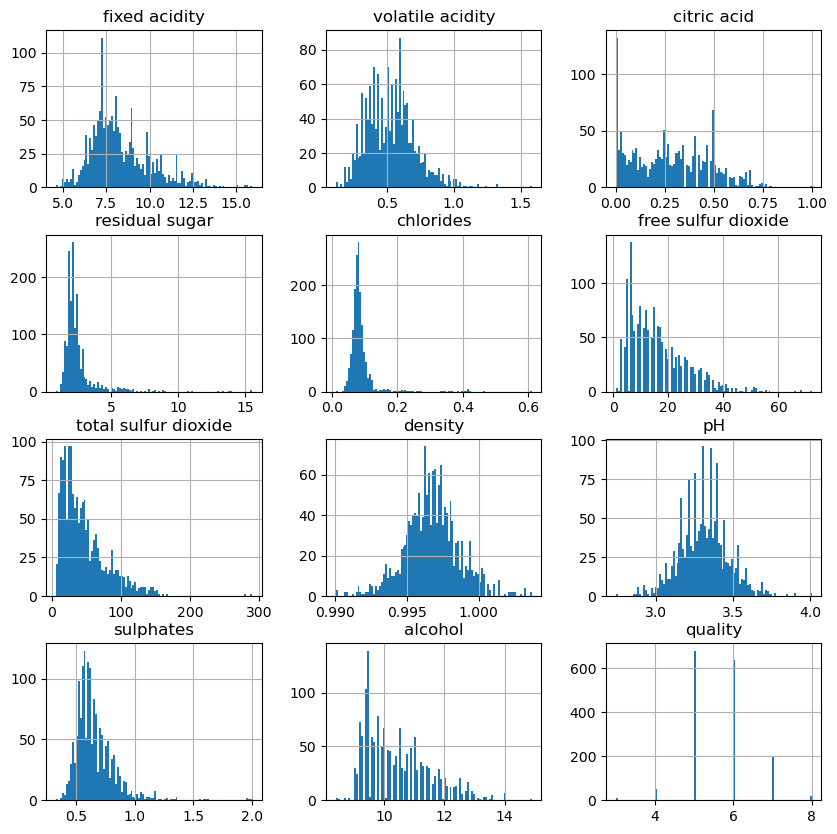

In [8]:
ax =Data.hist(figsize= (10,10),bins = 100)

Note: predicted qualities are **unbalanced** 


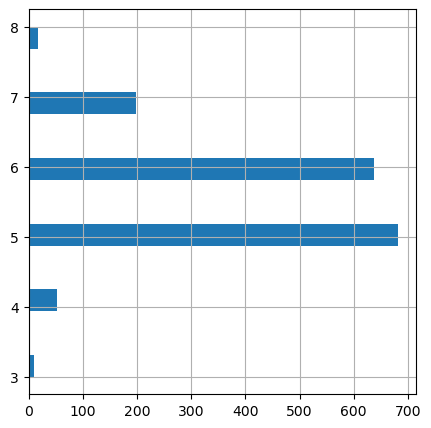

In [9]:
ax =Data['quality'].hist(figsize= (5,5),orientation="horizontal",bins = 16)
print('Note: predicted qualities are **unbalanced** ')

## Lets reduce the number of classes to three: low, medium, high

In [10]:

CodingQuality ={3:1,4:1,5:1,6:2,7:3,8:3}
Data['quality'] = Data['quality'].map(CodingQuality)

Note: predicted qualities are almost balanced 


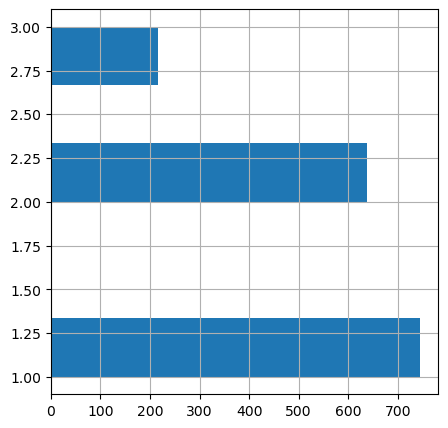

In [11]:
ax =Data['quality'].hist(figsize= (5,5),orientation="horizontal",bins = 6)
print('Note: predicted qualities are almost balanced ')

### Scatter plot.
**Note that the class quality is coded with a color, i.e. c =Data['quality']**

In [12]:
if False:
    ax = pd.plotting.scatter_matrix(Data,c =Data['quality'], figsize = (10,10))

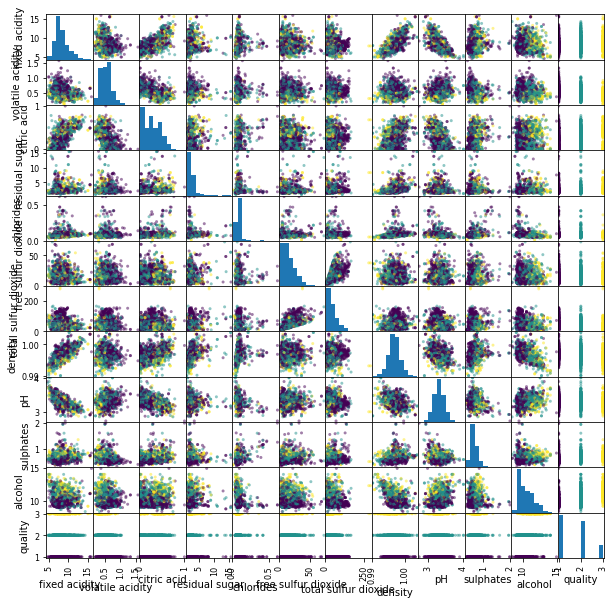

## Partition database into train and test

Note the helper function

In [13]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)

In [14]:
y = TrainDB['quality']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'quality']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
__________________________________________________


## Next we standarize the data, so that it has mean zero and standard deviation equal to one.

##  $z = {(x - mean) \over  std}$
### Important: Use the same scaler for the test database

In [15]:
scaler = StandardScaler()
print(scaler.fit(X))
X =scaler.transform(X)
X = pd.DataFrame(data = X, columns = InputFeatures)
X.describe().round(2).T
print('** Important: Use the same scaler for the test database!**')

StandardScaler()
** Important: Use the same scaler for the test database!**


## We create the projection into 2D by the two methods.

In [16]:
Dimension_of_projection = 2

In [17]:
lda = LinearDiscriminantAnalysis(n_components=Dimension_of_projection)
X_lda = lda.fit(X, y).transform(X)

X_lda = pd.DataFrame(data = X_lda, columns = ['dim1','dim2'])

## Homework: <font color='red'> State briefly the criterion for deriving each method and the underlying hypothesis.</font>

### Homework: <font color='red'>  Given a multidimensional Gaussian with $x \in \mathbb{R}^p$, which is the distribution of a linear combination of the dimensions of $x$ ?</font>

## Description of the projected elements

In [18]:
X_lda.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
dim1,1199.0,0.0,1.28,-3.54,-0.93,0.11,1.03,3.47
dim2,1199.0,-0.0,1.01,-8.56,-0.60,0.11,0.75,2.19


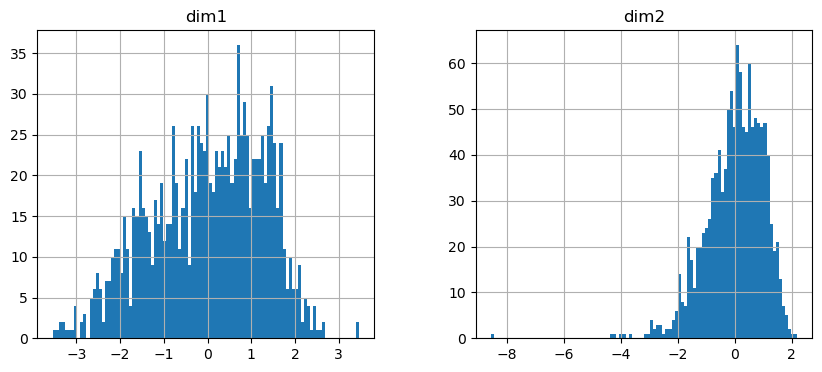

In [19]:
ax = X_lda.hist(figsize = (10,4),bins = 100)


## Homework: <font color='red'> Give a summary by words of the statistical distributions.</font>
1. Is the mean different from the percentile 50%. 
2. Is the std  deviation comparable to the interquantile distance (i.e. difference between the percentile 75% and the percentile 25%)
3. How many stds are the minimum and maximum from the mean value. Is it likely for a Gaussian?
4. <font color='red'> Do the hypothesis of the methods stand?.</font>  

## Lets look into the space of the projection

$P(.):x \in \mathbb{R}^{11} \longrightarrow   \mathbb{R}^2$ 

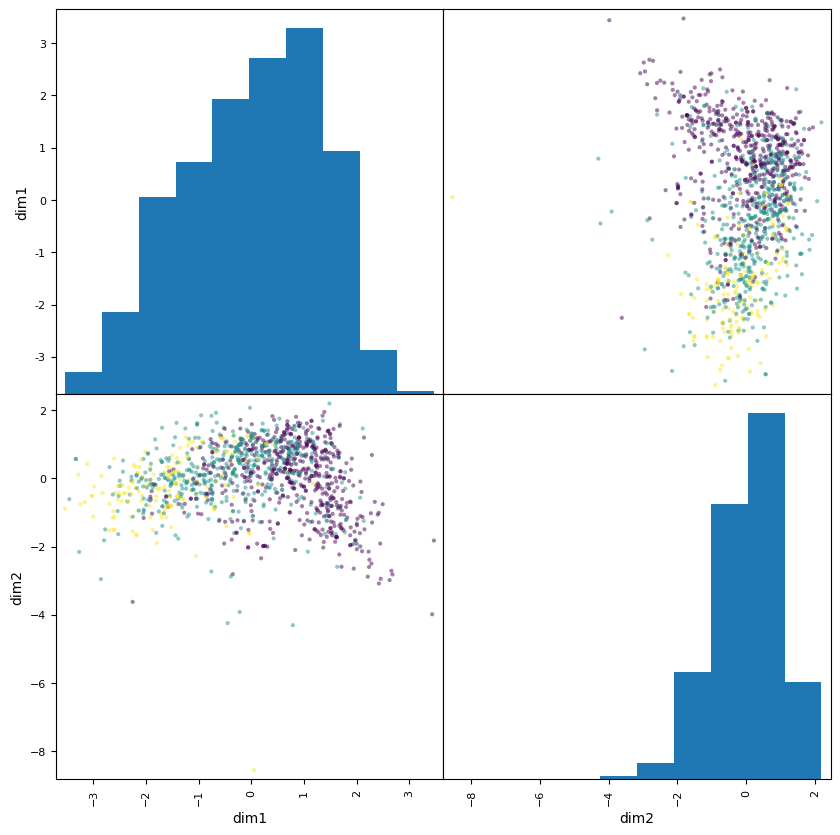

In [20]:
ax = pd.plotting.scatter_matrix(X_lda,c =y, figsize = (10,10))

In [21]:
lda.coef_[:1,:].shape


(1, 11)

In [22]:
Coef_Lda = pd.DataFrame(data = lda.coef_[:2,:].T, columns = ['Proj class 1','Proj class 2'],index =X.columns.values)
Coef_Lda

,Proj class 1,Proj class 2
fixed acidity,-0.220879,0.014630
volatile acidity,0.336712,-0.226448
citric acid,0.052126,-0.100579
residual sugar,-0.086408,-0.015137
chlorides,0.138622,-0.035754
free sulfur dioxide,-0.129995,0.110066
total sulfur dioxide,0.344469,-0.256058
density,0.158626,0.065139
pH,-0.025211,0.005660
sulphates,-0.325537,0.120046


Check what would have happened if we had not standarized.


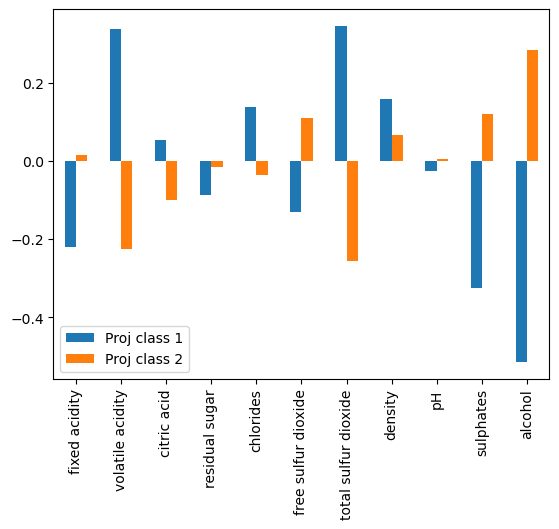

In [23]:
ax =Coef_Lda.plot.bar()
print('Check what would have happened if we had not standarized.')

In [24]:
print('Lets see how the means of each class compare to each other')
Means_Lda = pd.DataFrame(data = lda.means_.T, columns = ['Proj 1','Proj 2','Proj 3'],index =X.columns.values)
Means_Lda


Lets see how the means of each class compare to each other


,Proj 1,Proj 2,Proj 3
fixed acidity,-0.100709,0.015257,0.301689
volatile acidity,0.354550,-0.177353,-0.676319
citric acid,-0.178157,0.026234,0.536055
residual sugar,-0.016042,-0.027238,0.140630
chlorides,0.121896,-0.056653,-0.246006
free sulfur dioxide,0.084265,-0.050455,-0.134829
total sulfur dioxide,0.280695,-0.197214,-0.358190
density,0.166460,-0.075708,-0.341116
pH,-0.004519,0.051824,-0.146032
sulphates,-0.257963,0.103922,0.570444


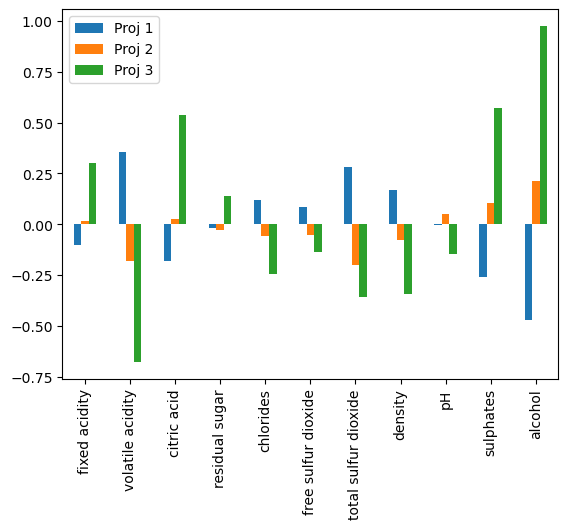

In [25]:
ax =Means_Lda.plot.bar()

## Homework: 

1. <font color='red'> Comment on the meaning of the coefficients. What is the result of having different signs and sizes of the values?</font>
2. <font color='red'> If you have time, what would have happened if we had not standarized? What is the influence of the size/order of magnitude of the features?</font>
3. <font color='red'> What can you say about the means in the sense of separation between classes? Note that there seems to be like a continuity between the centers of mass for each quality.</font>

## Homework: 

1. <font color='red'>  Create three logistic linear classifiers: Class 1 vs. {Class 2 and class 3}, Class 2 vs. {Class 1 and class 3}, Class 3 vs. {Class 1 and class 2}</font>
**Is there a difference between the performance on train and test?**

2. <font color='red'>  Do the classification on the original data, and on the data after the **lda** projection</font>
3. <font color='red'>   From the coefficients of the lda and  logistic linear classifiers, and the understanding of the problem, can you think of a feature engineering that might improve the problem</font>
4. **Remember: the 'l2' option in the logistic classifier does a regularization function.**

## Description of variables: Wine  quality
### Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
Output variable (based on sensory data): 
12. quality (score between 0 and 10)
